In [3]:
import os
import pynwb
import h5py
from tqdm import tqdm
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import pywt
import matplotlib
import graph
import time
import pickle
import itertools

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec

import statsmodels.api as sm
from scipy import signal
from scipy.fftpack import next_fast_len
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter1d
from scipy.signal import filtfilt, hilbert, remez, sosfiltfilt, butter, find_peaks, detrend
import pingouin as pg
from scipy.stats import fisher_exact
from pycircstat2.correlation import circ_corrcl
from pycircstat2.hypothesis import watson_williams_test
from pycircstat2.regression import CLRegression

import load_data
import LFP
import single_neuron_vis

In [91]:
def epoch_aligned_lfp_spike(date,df,window):
    
    timestamps, lfpData = load_data.load_LFP(date)
    lfpFile = h5py.File(f'D:/Teleworld/bart_I/raw/spikes/Bart_TeleWorld_v13_{date}-spikes.mat', 'r')
    spikeTable = lfpFile['spikeTable'][:len(timestamps), :]

    num_ch = lfpData.shape[1]
    num_units = spikeTable.shape[1]
    aligned_lfp = np.zeros((len(df),num_ch,window[1]-window[0]))  # 1 if happened during ITI, 0 if during a trial
    aligned_spikes = np.zeros((len(df),num_units,window[1]-window[0]))
    
    for ii in range(len(df)):

        on = df.iloc[ii].t_on.astype(float)
        idx = (timestamps>on+window[0]) & (timestamps<on+window[1])
        aligned_lfp[ii,:,:] = lfpData[idx,:].T.astype(np.float32)
        aligned_spikes[ii,:,:] = spikeTable[idx,:].T
    
    return np.array(aligned_lfp), np.array(aligned_spikes)

In [142]:
def extract_wavelet_phase(sig, fs=1000):

    # notch filter 60hz and harmonics
    
    lfp_filt = sig.copy()
    for f0 in [60, 120, 180, 240]:# design 10th order band-stop (Butterworth) filter for each noise frequency +/- 2 Hz
        notchfilt = butter(10, (f0-2,f0+2), 'bandstop', fs=1000, output='sos')
        lfp_filt = sosfiltfilt(notchfilt, lfp_filt)
    
    detrended = detrend(lfp_filt)  
    
    # Define frequencies of interest (1 to 100 Hz, logarithmically spaced)
    freqs = np.logspace(np.log10(2), np.log10(128), num=40)
    
    # Convert frequencies to scales for Morlet wavelet in pywt
    # The formula depends on the wavelet center frequency:
    wavelet = 'cmor1.5-1.0'  # complex Morlet with bandwidth=1.5, center freq=1.0
    center_freq = pywt.central_frequency(wavelet)
    scales = center_freq * fs / freqs
    

    # Compute the Continuous Wavelet Transform (CWT)
    coeffs, frequencies = pywt.cwt(detrended, scales, wavelet, sampling_period=1/fs)
    
    # Compute power (magnitude squared of coefficients)
    phase = np.angle(coeffs)   # instantaneous phase
    power = np.abs(coeffs) ** 2

    return frequencies, phase.astype(np.float32), power.astype(np.float32)

In [46]:
date = '031723'
nwbfile = load_data.load_nwbfile('Bart',date) 
df = nwbfile.intervals['node_on'].to_dataframe()
df = graph.append_use_tele(df)

# get unit information
unit_params = {"drift": 2, "min_fr": 1}
unitNames = nwbfile.units.to_dataframe()
unit_idx =  np.where((unitNames.group == "good") & (unitNames.drift <= unit_params["drift"]) & (unitNames.fr >= unit_params["min_fr"]))[0]

In [37]:
aligned_lfp, aligned_spikes = epoch_aligned_lfp_spike(date,df,[-1000,1500])

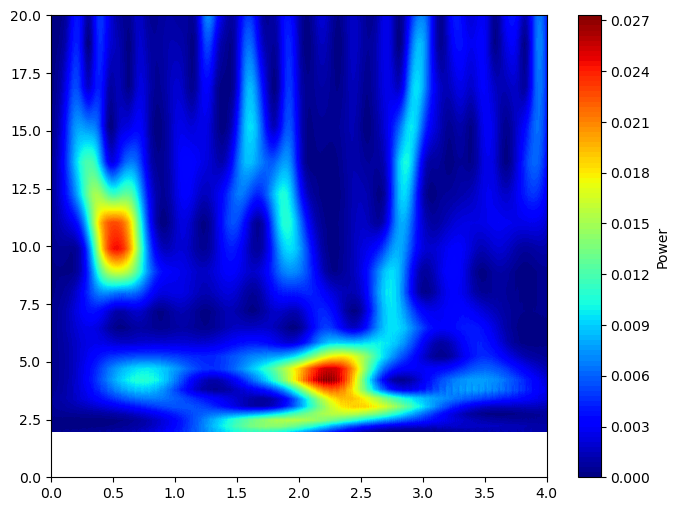

In [48]:
plt.close('all')
plt.figure(figsize=(8, 6))
plt.contourf(np.linspace(0,4,2500), frequencies, power, 100, cmap='jet')
# plt.yscale('log')
plt.ylim(0,20)
plt.colorbar(label='Power')

In [227]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [246]:
n_ts = 2500
power = np.zeros((len(df),40,n_ts))
for trial in range(len(df)):
    frequencies, _, power[trial,:] = extract_wavelet_phase(aligned_lfp[trial,channel,:])

In [248]:
# scan across time and frequency to see which time and frequecy is modulated by value

nav_idx = df.trialerror==0
nav_df = df[nav_idx]
X = sm.add_constant(np.clip(nav_df.graph_distance.values,0,3))
power_coef = np.zeros(power.shape[1:])
power_pval = np.zeros(power.shape[1:])

for ff in range(len(frequencies)):
    for tt in range(n_ts):
        Y = power[nav_idx,ff,tt].reshape((-1,1))
        model = sm.OLS(Y,X).fit()
        power_coef[ff,tt] = model.params[1]
        power_pval[ff,tt] = model.pvalues[1]

In [255]:
power_coef.max()

np.float64(0.006611600301383157)

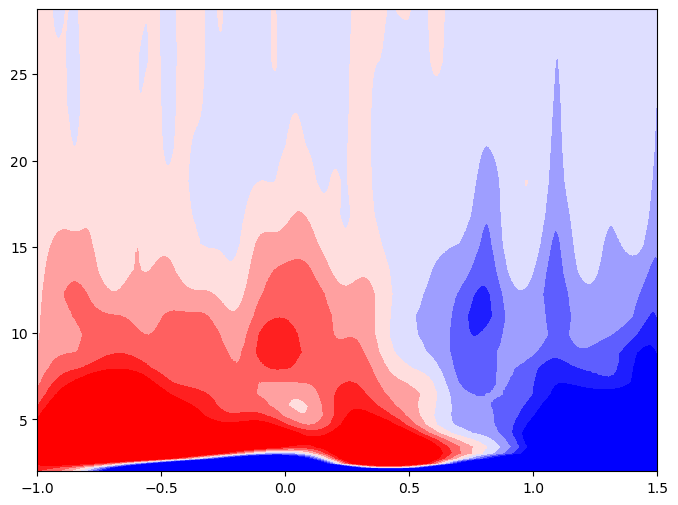

In [265]:
plt.close('all')
cmin = -0.002
cmax = 0.002
norm = mcolors.Normalize(vmin=cmin, vmax=cmax, clip=True)

idx = (frequencies>0) & (frequencies<30)

plt.figure(figsize=(8, 6))
plt.contourf(np.linspace(-1,1.5,2500), frequencies[idx], power_coef[idx,:], levels = 100,norm = norm, cmap='bwr')
# plt.ylim(0,10)


In [143]:
# spike-LFP coherence

n_ts = 1000
n_cell = len(unit_idx)
phase_pval = np.zeros((n_cell,len(frequencies),2))
phase_coef = np.zeros((n_cell,len(frequencies),2))
total_pval = np.zeros((n_cell,len(frequencies)))

for ii, unit in tqdm(enumerate(unit_idx)):
    
    channel = unitNames.iloc[unit].channelNumbers - 1     # channel numbers are 1-192, for indexing -1
    
    # 1. first extract instantaneous phase for all frequencies using wavelet
    
    spiketrain = np.zeros((len(df),n_ts))
    phase = np.zeros((len(df),40,n_ts))
    power = np.zeros((len(df),40,n_ts))
    
    for trial in range(len(df)):
        
        spiketrain[trial,:] = aligned_spikes[trial,unit,1000:2000]
        frequencies, phase[trial,:], power[trial,:] = extract_wavelet_phase(aligned_lfp[trial,channel,1000:2000])
    
    # 2. use poisson GLM to model spike-LFP coherence
    
    Y = spiketrain.ravel()
    
    # compare GLM model with LFP phase and without phase as predictors
    X0 = np.ones(np.shape(Y))                               #Define constant predictor.
    null_model = sm.GLM(Y,X0,family=sm.families.Poisson())  #Define reduced model.
    null_res   = null_model.fit()                           #Fit reduced model.
    
    for ff in range(len(frequencies)):
    
        phase_alltrial = phase[:,ff,:].ravel()
        X =  np.transpose([np.ones(len(phase_alltrial)), np.cos(phase_alltrial), np.sin(phase_alltrial)])
        model = sm.GLM(Y,X,family=sm.families.Poisson())    # Build the GLM model,
        res = model.fit()                                 # ... and fit it,
        phase_coef[ii,ff,:] = res.params[1:]
        phase_pval[ii,ff,:] = res.pvalues[1:]
        total_pval[ii,ff] = 1-scipy.stats.chi2.cdf(null_res.deviance-res.deviance,2) #Compare two nested GLMs.
        

170it [6:54:37, 146.34s/it]


In [147]:
def plot_sem(time, trace, ax, label, color):

    mean_trace = trace.mean(axis=0)
    sem_trace = trace.std(axis=0)/np.sqrt(trace.shape[0])
    ax.plot(time, mean_trace, color=color, label=label)
    ax.fill_between(time,
                    mean_trace - sem_trace,
                    mean_trace + sem_trace,
                    color=color,
                    alpha=0.3)

In [185]:
A = phase_coef[:,:,0]**2 + phase_coef[:,:,1]**2

In [ ]:
pvals = phase_pval[:,:,1]
pvals_safe = np.clip(pvals, 1e-300, 1.0)
log_pvals = -np.log(pvals_safe)

In [169]:
ofc_idx = unitNames.iloc[unit_idx].region.values=='OFC'

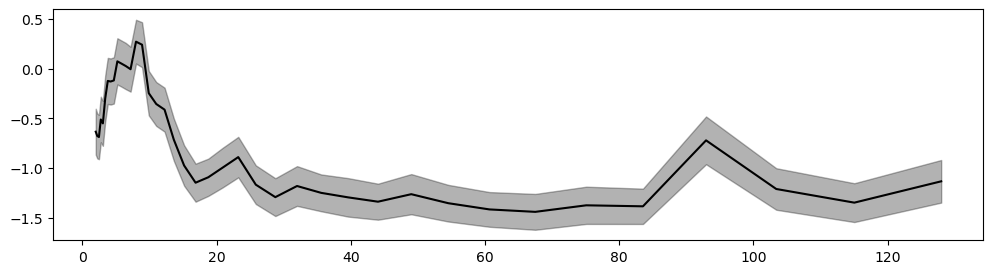

In [182]:
plt.close('all')
fig, ax = plt.subplots()
plot_sem(frequencies,np.atan2(phase_coef[ofc_idx,:,1],phase_coef[ofc_idx,:,0]), ax, '', 'k')

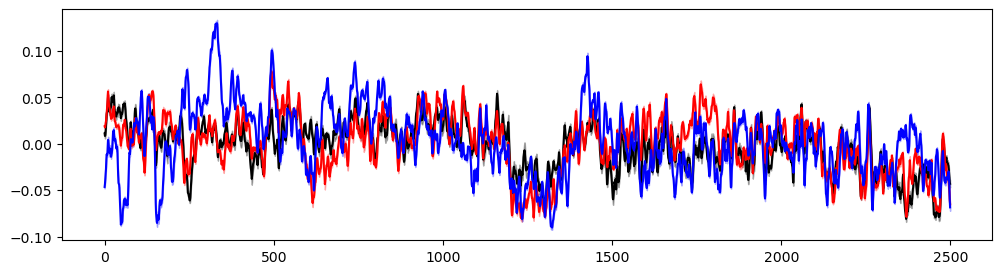

In [193]:
plt.close('all')
fig, ax = plt.subplots()
plot_sem(np.arange(2500),aligned_lfp[0,:32,:], ax, '', 'k')
plot_sem(np.arange(2500),aligned_lfp[0,32:64,:], ax, '', 'r')
plot_sem(np.arange(2500),aligned_lfp[0,160:192,:], ax, '', 'b')

(0.0, 0.05)

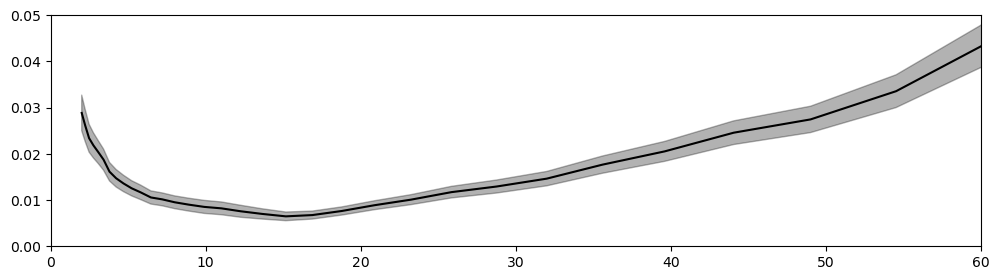

In [188]:
plt.close('all')
fig, ax = plt.subplots()
plot_sem(frequencies,A, ax, '', 'k')
plt.xlim(0,60)
plt.ylim(0,0.05)

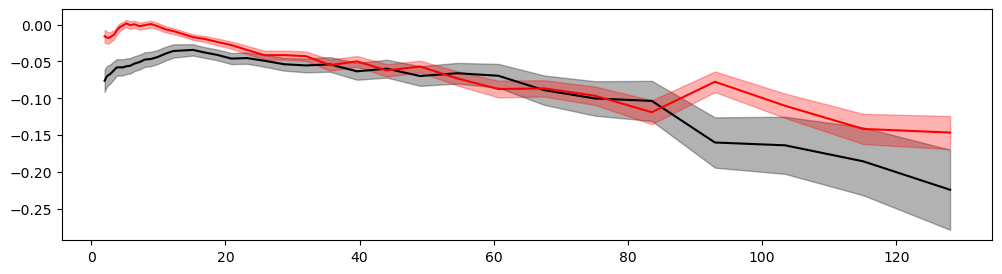

In [174]:
plt.close('all')
fig, ax = plt.subplots()
plot_sem(frequencies, phase_coef[ofc_idx,:,0], ax, '', 'k') 
plot_sem(frequencies, phase_coef[ofc_idx,:,1], ax, '', 'r') 
# plt.xlim(0,20)
# plt.ylim(-0.15,0.05)
# plt.axvline(4)
# plt.axvline(8)

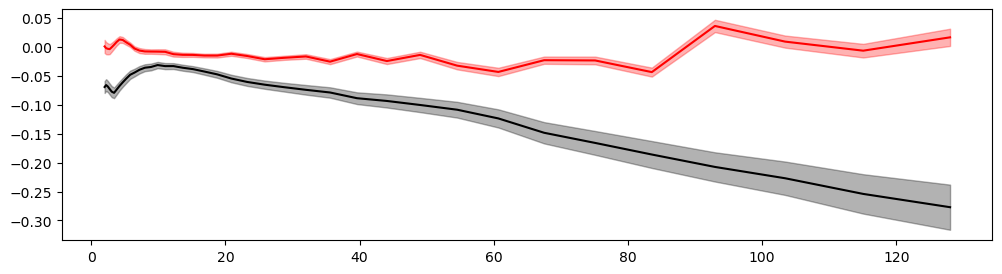

In [175]:
plt.close('all')
fig, ax = plt.subplots()
plot_sem(frequencies, phase_coef[~ofc_idx,:,0], ax, '', 'k') 
plot_sem(frequencies, phase_coef[~ofc_idx,:,1], ax, '', 'r') 
# plt.xlim(0,20)
# plt.ylim(-0.15,0.05)
# plt.axvline(4)
# plt.axvline(8)

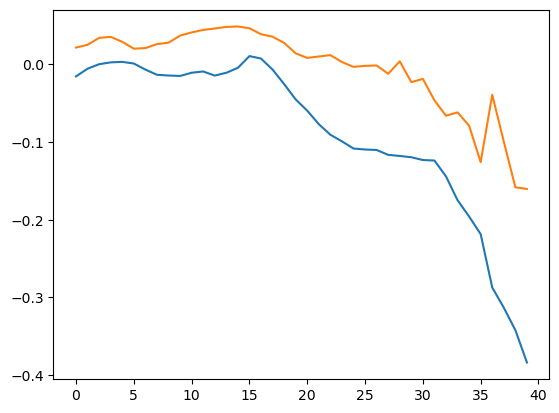

In [114]:
plt.plot(phase_coef[0,:,:])

C:\Users\Admin\AppData\Local\Temp\ipykernel_2952\3789059085.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(-np.log(phase_pval[0,:,:]))


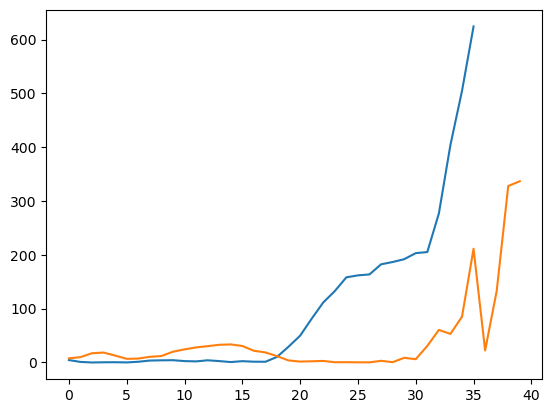

In [116]:
plt.plot(-np.log(phase_pval[0,:,:]))

In [122]:
def coherence(n,y,t):                           #INPUT (spikes, fields, time)
    
    K = shape(n)[0]                          #... where spikes and fields are arrays [trials, time]
    N = shape(n)[1]
    T = t[-1]
    SYY = zeros(int(N/2+1))
    SNN = zeros(int(N/2+1))
    SYN = zeros(int(N/2+1), dtype=complex)
    
    for k in arange(K):
        yf = rfft((y[k,:]-mean(y[k,:])) *hanning(N))    # Hanning taper the field,
        nf = rfft((n[k,:]-mean(n[k,:])))                # ... but do not taper the spikes.
        SYY = SYY + ( real( yf*conj(yf) ) )/K           # Field spectrum
        SNN = SNN + ( real( nf*conj(nf) ) )/K           # Spike spectrum
        SYN = SYN + ( yf*conj(nf) )/K                   # Cross spectrum

    cohr = abs(SYN) / sqrt(SYY) / sqrt(SNN)             # Coherence
    f = rfftfreq(N, dt)                                 # Frequency axis for plotting
    
    return (cohr, f, SYY, SNN, SYN)

In [124]:
from pylab import *

In [201]:
dt=0.001
cohr = np.zeros((1251,len(unit_idx)))
for ii, unit in tqdm(enumerate(unit_idx)):
    channel = unitNames.iloc[unit].channelNumbers - 1     # channel numbers are 1-192, for indexing -1
    cohr[:,ii], f, SYY, SNN, SYN = coherence(aligned_spikes[:,unit,:],aligned_lfp[:,channel,:],np.arange(-1000,1500))

170it [01:13,  2.31it/s]


(0.0, 40.0)

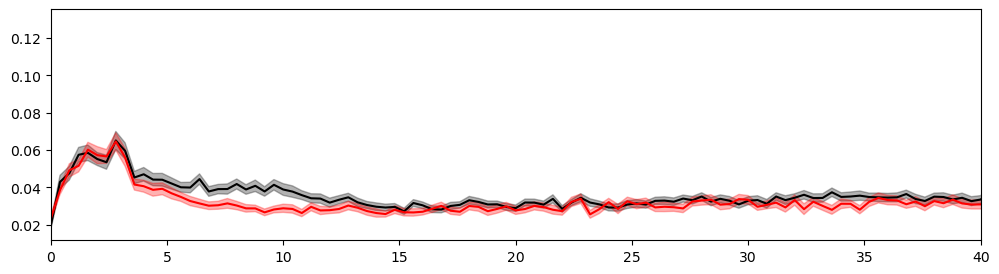

In [207]:
plt.close('all')
fig, ax = plt.subplots()
plot_sem(f, cohr.T[ofc_idx], ax, '', 'k') 
plot_sem(f, cohr.T[~ofc_idx], ax, '', 'r') 
# plt.plot(cohr[f<60,:])
plt.xlim(0,40)

(0.0, 80.0)

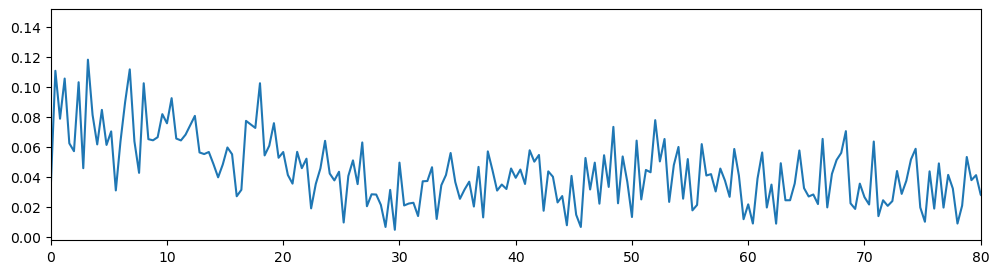

In [199]:
plt.close('all')
plt.plot(f,cohr)
plt.xlim(0,80)

In [119]:
plv = np.zeros(len(frequencies))

for ff in range(len(frequencies)):

    phase_alltrial = phase[:,ff,:].ravel()
    z = np.exp(1j * phase_alltrial)
    plv[ff] = np.abs(np.mean(z * Y)) / np.mean(Y)

In [176]:
plv

array([0.04198522, 0.04007002, 0.03810453, 0.03819445, 0.03420781,
       0.03281163, 0.03323939, 0.03479266, 0.03378534, 0.03639385,
       0.03711817, 0.03890631, 0.04221614, 0.04596249, 0.04780176,
       0.04789712, 0.0460612 , 0.03903886, 0.02998974, 0.02748557,
       0.03446702, 0.04261005, 0.04619399, 0.0477657 , 0.04493154,
       0.04329957, 0.04398157, 0.04617199, 0.04619991, 0.05122128,
       0.05054119, 0.05159131, 0.05688705, 0.0625455 , 0.06736932,
       0.07330407, 0.08180368, 0.09325232, 0.11135537, 0.12961342])

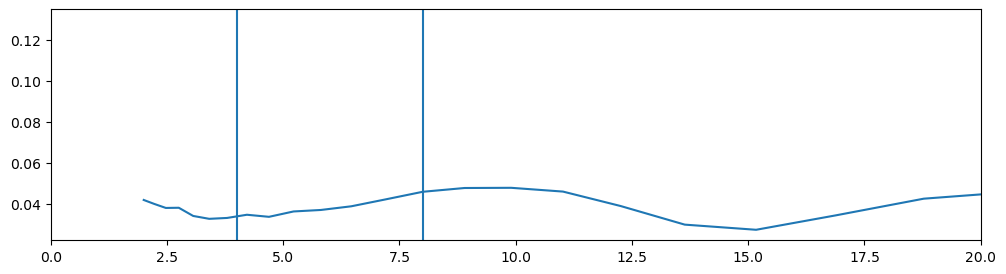

In [178]:
plt.plot(frequencies,plv)
plt.xlim(0,20)
# plt.ylim(-0.15,0.05)
plt.axvline(4)
plt.axvline(8)

In [109]:
null_model.fit() 

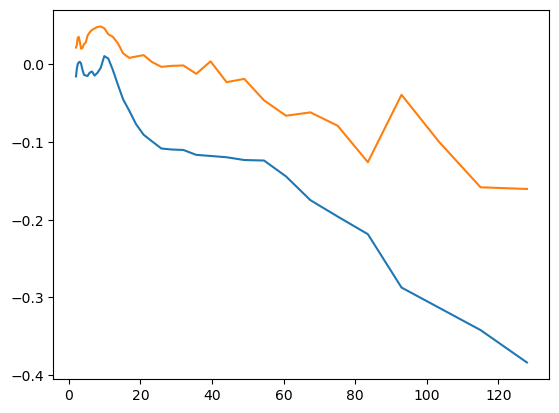

In [65]:
plt.close('all')
plt.plot(frequencies,phase_coef)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2952\260473238.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(frequencies,-np.log(phase_pval))
C:\Users\Admin\AppData\Local\Temp\ipykernel_2952\260473238.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(frequencies,-np.log(total_pval))


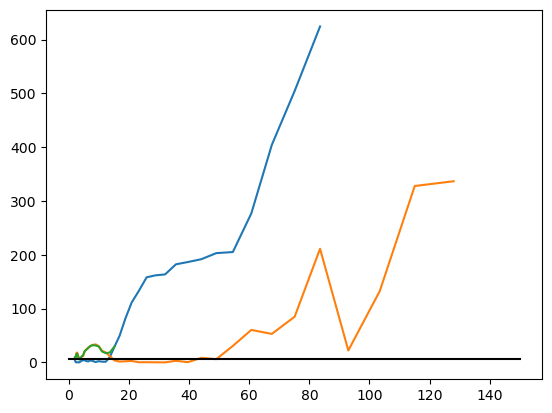

In [85]:
plt.close('all')
plt.plot(frequencies,-np.log(phase_pval))
plt.plot(frequencies,-np.log(total_pval))
plt.plot([0,150],[-np.log(0.001),-np.log(0.001)],'k-')

# plt.xlim(0,20)
# plt.ylim(0,50)